In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import warnings
warnings.filterwarnings('ignore')

#### Loading the dataset

In [2]:
data = pd.read_csv("yellow_tripdata.csv")
data.head()         

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,2015-01-15 19:05:39,2015-01-15 19:23:42,1,1.59,-73.993896,40.750111,1,N,-73.974785,40.750618,1.0,12.0,1.0,0.5,3.25,0.0,0.3,17.05
1,1,2015-01-10 20:33:38,2015-01-10 20:53:28,1,3.30,-74.001648,40.724243,1,N,-73.994415,40.759109,1.0,14.5,0.5,0.5,2.00,0.0,0.3,17.80
2,1,2015-01-10 20:33:38,2015-01-10 20:43:41,1,1.80,-73.963341,40.802788,1,N,-73.951820,40.824413,2.0,9.5,0.5,0.5,0.00,0.0,0.3,10.80
3,1,2015-01-10 20:33:39,2015-01-10 20:35:31,1,0.50,-74.009087,40.713818,1,N,-74.004326,40.719986,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80
4,1,2015-01-10 20:33:39,2015-01-10 20:52:58,1,3.00,-73.971176,40.762428,1,N,-74.004181,40.742653,2.0,15.0,0.5,0.5,0.00,0.0,0.3,16.30


#### Exploratory Data Analysis

In [4]:
data.shape

(4375301, 19)

In [5]:
data.dtypes

VendorID                   int64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count            int64
trip_distance            float64
pickup_longitude         float64
pickup_latitude          float64
RateCodeID                 int64
store_and_fwd_flag        object
dropoff_longitude        float64
dropoff_latitude         float64
payment_type             float64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
dtype: object

In [6]:
data['tpep_dropoff_datetime'] = pd.to_datetime(data['tpep_dropoff_datetime'])
data['tpep_pickup_datetime'] = pd.to_datetime(data['tpep_pickup_datetime'])

In [7]:
data['duration'] = data['tpep_dropoff_datetime'] - data['tpep_pickup_datetime']
data['duration'] = data['duration'].dt.total_seconds()/60
data.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration
0,2,2015-01-15 19:05:39,2015-01-15 19:23:42,1,1.59,-73.993896,40.750111,1,N,-73.974785,40.750618,1.0,12.0,1.0,0.5,3.25,0.0,0.3,17.05,18.050000
1,1,2015-01-10 20:33:38,2015-01-10 20:53:28,1,3.30,-74.001648,40.724243,1,N,-73.994415,40.759109,1.0,14.5,0.5,0.5,2.00,0.0,0.3,17.80,19.833333
2,1,2015-01-10 20:33:38,2015-01-10 20:43:41,1,1.80,-73.963341,40.802788,1,N,-73.951820,40.824413,2.0,9.5,0.5,0.5,0.00,0.0,0.3,10.80,10.050000
3,1,2015-01-10 20:33:39,2015-01-10 20:35:31,1,0.50,-74.009087,40.713818,1,N,-74.004326,40.719986,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,1.866667
4,1,2015-01-10 20:33:39,2015-01-10 20:52:58,1,3.00,-73.971176,40.762428,1,N,-74.004181,40.742653,2.0,15.0,0.5,0.5,0.00,0.0,0.3,16.30,19.316667


In [9]:
# Extract features that influence traffic and taxi duration
data['pickup_hour'] = data['tpep_pickup_datetime'].dt.hour
data['day_of_week'] = data['tpep_pickup_datetime'].dt.dayofweek  # 0=Monday, 6=Sunday

In [11]:
data['is_weekend'] = data['day_of_week'].isin([5, 6]).astype(int)

In [12]:
data.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'pickup_longitude',
       'pickup_latitude', 'RateCodeID', 'store_and_fwd_flag',
       'dropoff_longitude', 'dropoff_latitude', 'payment_type', 'fare_amount',
       'extra', 'mta_tax', 'tip_amount', 'tolls_amount',
       'improvement_surcharge', 'total_amount', 'duration', 'pickup_hour',
       'day_of_week', 'is_weekend'],
      dtype='object')

In [14]:
df = data[['passenger_count', 'trip_distance','payment_type', 'fare_amount', 'duration','pickup_hour', 'day_of_week', 'is_weekend']]

In [15]:
df.head()

,passenger_count,trip_distance,payment_type,fare_amount,duration,pickup_hour,day_of_week,is_weekend
0,1,1.59,1.0,12.0,18.050000,19,3,0
1,1,3.30,1.0,14.5,19.833333,20,5,1
2,1,1.80,2.0,9.5,10.050000,20,5,1
3,1,0.50,2.0,3.5,1.866667,20,5,1
4,1,3.00,2.0,15.0,19.316667,20,5,1


In [16]:
df.isnull().sum()

passenger_count    0
trip_distance      0
payment_type       1
fare_amount        1
duration           0
pickup_hour        0
day_of_week        0
is_weekend         0
dtype: int64

In [17]:
df.dropna(inplace=True)

In [18]:
df.isna().sum()

passenger_count    0
trip_distance      0
payment_type       0
fare_amount        0
duration           0
pickup_hour        0
day_of_week        0
is_weekend         0
dtype: int64

In [19]:
df['payment_type'] = df['payment_type'].astype('int64')

In [20]:
df[df.duplicated()]


,passenger_count,trip_distance,payment_type,fare_amount,duration,pickup_hour,day_of_week,is_weekend
4017,1,1.28,1,7.5,8.666667,18,1,0
8924,1,0.70,1,5.0,4.166667,0,5,1
9481,1,1.70,1,9.0,10.150000,16,1,0
16282,1,1.97,1,8.5,7.550000,20,0,0
16451,1,2.40,1,12.0,14.783333,7,3,0
...,...,...,...,...,...,...,...,...
4375261,1,0.80,1,5.0,4.166667,16,5,1
4375280,2,0.90,2,5.5,4.866667,22,4,0
4375283,1,1.20,1,7.0,7.366667,22,4,0
4375284,1,0.60,1,5.0,4.350000,22,4,0


In [21]:
df.drop_duplicates(inplace=True)

In [22]:
df['payment_type'].value_counts(normalize=True)

payment_type
1    0.615660
2    0.380235
3    0.003140
4    0.000965
Name: proportion, dtype: float64

In [23]:
df = df[df['payment_type']<3]
df['payment_type'].unique()

array([1, 2])

In [24]:
df['passenger_count'].value_counts(normalize=True)

passenger_count
1    6.925437e-01
2    1.479825e-01
5    5.727754e-02
3    4.340357e-02
6    3.743151e-02
4    2.081205e-02
0    5.457671e-04
7    1.206915e-06
8    1.206915e-06
9    9.655322e-07
Name: proportion, dtype: float64

In [25]:
df = df[(df['passenger_count'] >0) & (df['passenger_count'] < 6 )]

In [26]:
df.shape

(3985447, 8)

In [27]:
df['payment_type'].replace([1,2],['Card','Cash'],inplace=True)

In [28]:
df.describe()

,passenger_count,trip_distance,fare_amount,duration,pickup_hour,day_of_week,is_weekend
count,3.985447e+06,3.985447e+06,3.985447e+06,3.985447e+06,3.985447e+06,3.985447e+06,3.985447e+06
mean,1.547116e+00,9.085039e+00,1.220153e+01,1.532177e+01,1.356747e+01,3.249637e+00,3.083677e-01
std,1.087329e+00,7.207241e+03,1.048754e+01,8.902532e+02,6.448459e+00,1.859311e+00,4.618193e-01
min,1.000000e+00,0.000000e+00,-4.500000e+02,-9.855000e+02,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,1.010000e+00,6.500000e+00,6.333333e+00,9.000000e+00,2.000000e+00,0.000000e+00
50%,1.000000e+00,1.710000e+00,9.000000e+00,1.028333e+01,1.400000e+01,3.000000e+00,0.000000e+00
75%,2.000000e+00,3.120000e+00,1.400000e+01,1.620000e+01,1.900000e+01,5.000000e+00,1.000000e+00
max,5.000000e+00,1.180000e+07,3.005500e+03,5.485556e+05,2.300000e+01,6.000000e+00,1.000000e+00


In [29]:
df = df[df['fare_amount'] > 0]
df = df[df['duration'] > 0]

In [30]:
df =df[df['trip_distance'] > 0]

{'whiskers': [<matplotlib.lines.Line2D at 0x2a5d4701810>,
 'caps': [<matplotlib.lines.Line2D at 0x2a5d4791bd0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2a5d4703250>],
 'medians': [<matplotlib.lines.Line2D at 0x2a5d4791e50>],
 'fliers': [<matplotlib.lines.Line2D at 0x2a5d4791f90>],
 'means': []}

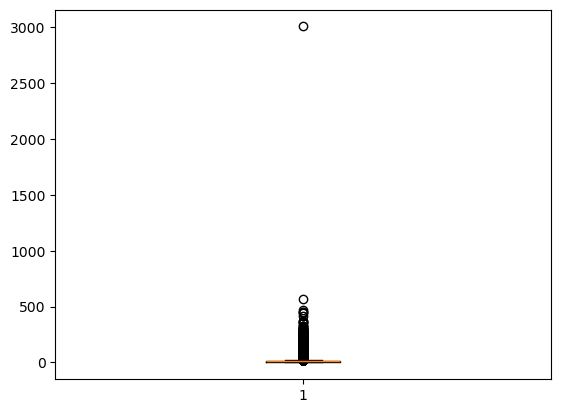

In [31]:
plt.boxplot(df['fare_amount'])

In [32]:
df.columns

Index(['passenger_count', 'trip_distance', 'payment_type', 'fare_amount',
       'duration', 'pickup_hour', 'day_of_week', 'is_weekend'],
      dtype='object')

In [33]:
for col in ['fare_amount','trip_distance','duration']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    Iqr =q3 -q1
    lower_bound = q1 - 1.5 * Iqr
    upper_bound = q3 + 1.5 * Iqr
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
df

,passenger_count,trip_distance,payment_type,fare_amount,duration,pickup_hour,day_of_week,is_weekend
0,1,1.59,Card,12.0,18.050000,19,3,0
1,1,3.30,Card,14.5,19.833333,20,5,1
2,1,1.80,Cash,9.5,10.050000,20,5,1
3,1,0.50,Cash,3.5,1.866667,20,5,1
4,1,3.00,Cash,15.0,19.316667,20,5,1
...,...,...,...,...,...,...,...,...
4375294,1,0.80,Card,5.0,3.250000,22,4,0
4375295,1,1.30,Cash,10.5,14.016667,16,5,1
4375297,1,3.10,Cash,14.5,19.433333,16,5,1
4375298,1,1.79,Cash,9.0,10.450000,16,5,1


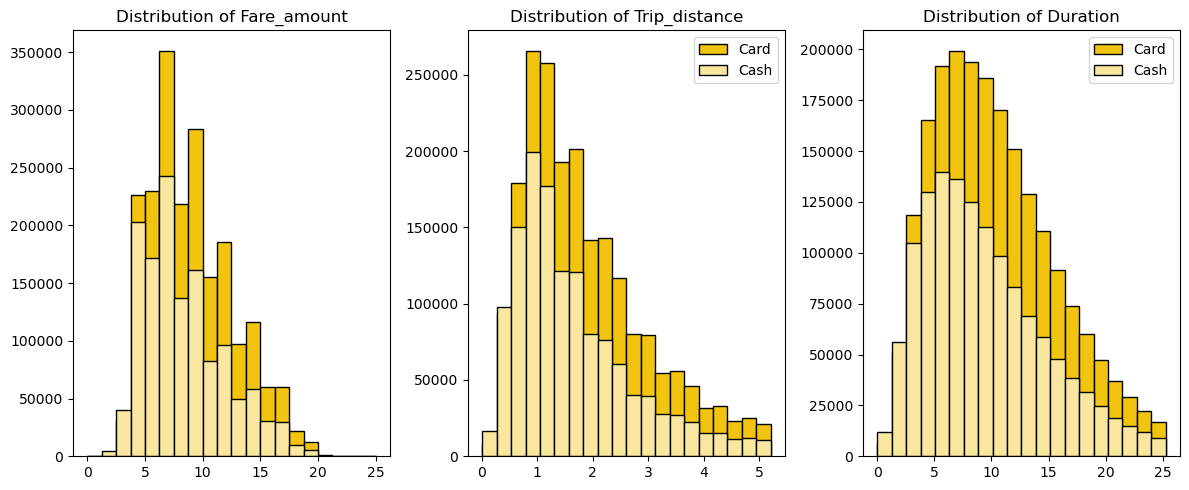

In [34]:
plt.figure(figsize = (12,5))
plt.subplot(1,3,1)
plt.title("Distribution of Fare_amount")
plt.hist(df[df['payment_type'] =='Card']['fare_amount'],histtype = 'barstacked',bins =20,edgecolor = 'k',color = '#F1C40F',label= 'Card')
plt.hist(df[df['payment_type'] =='Cash']['fare_amount'],histtype = 'barstacked',bins =20,edgecolor = 'k',color = '#F9E79F',label = 'Cash')



plt.subplot(1,3,2)
plt.title("Distribution of Trip_distance")
plt.hist(df[df['payment_type'] =='Card']['trip_distance'],histtype = 'barstacked',bins =20,edgecolor = 'k',color = '#F1C40F',label= 'Card')
plt.hist(df[df['payment_type'] =='Cash']['trip_distance'],histtype = 'barstacked',bins =20,edgecolor = 'k',color = '#F9E79F',label = 'Cash')
plt.legend()


plt.subplot(1,3,3)
plt.title("Distribution of Duration")
plt.hist(df[df['payment_type'] =='Card']['duration'],histtype = 'barstacked',bins =20,edgecolor = 'k',color = '#F1C40F',label= 'Card')
plt.hist(df[df['payment_type'] =='Cash']['duration'],histtype = 'barstacked',bins =20,edgecolor = 'k',color = '#F9E79F',label = 'Cash')
plt.legend()

plt.tight_layout()
plt.show()

In [35]:
df.groupby('payment_type').agg({'fare_amount':['mean','std'],'trip_distance' : ['mean','std'],'duration' : ['mean','std']})

fare_amount           trip_distance             duration  \
                    mean       std          mean       std       mean   
payment_type                                                            
Card            9.213815  3.609376      1.861339  1.100253  10.283686   
Cash            8.487536  3.547432      1.645575  1.059590   9.355443   

                        
                   std  
payment_type            
Card          5.221901  
Cash          5.211266

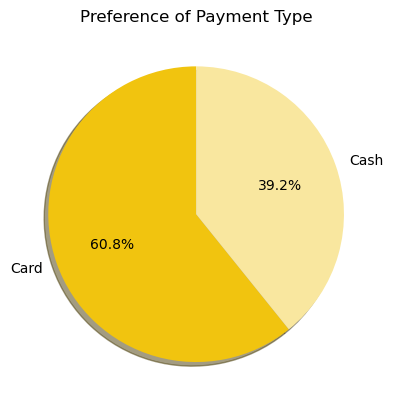

In [36]:
plt.title("Preference of Payment Type")
plt.pie(df['payment_type'].value_counts(normalize=True), labels = df['payment_type'].value_counts().index,
        startangle=90, shadow =True,autopct = '%1.1f%%', colors = ['#F1C40F', '#F9E79F',])
plt.show()

In [37]:
df

,passenger_count,trip_distance,payment_type,fare_amount,duration,pickup_hour,day_of_week,is_weekend
0,1,1.59,Card,12.0,18.050000,19,3,0
1,1,3.30,Card,14.5,19.833333,20,5,1
2,1,1.80,Cash,9.5,10.050000,20,5,1
3,1,0.50,Cash,3.5,1.866667,20,5,1
4,1,3.00,Cash,15.0,19.316667,20,5,1
...,...,...,...,...,...,...,...,...
4375294,1,0.80,Card,5.0,3.250000,22,4,0
4375295,1,1.30,Cash,10.5,14.016667,16,5,1
4375297,1,3.10,Cash,14.5,19.433333,16,5,1
4375298,1,1.79,Cash,9.0,10.450000,16,5,1


In [38]:
passenger_count = df.groupby(['payment_type','passenger_count'])[['passenger_count']].count()
passenger_count.rename(columns = {'passenger_count':'count'},inplace= True)
passenger_count.reset_index(inplace = True)

In [39]:
passenger_count['perc'] = (passenger_count['count']/passenger_count['count'].sum()) *100

In [40]:
passenger_count

,payment_type,passenger_count,count,perc
0,Card,1,1495381,44.345124
1,Card,2,304150,9.019487
2,Card,3,87851,2.605198
3,Card,4,38760,1.149417
4,Card,5,123750,3.669773
5,Cash,1,932887,27.664515
6,Cash,2,211454,6.270612
7,Cash,3,65512,1.942741
8,Cash,4,34532,1.024037
9,Cash,5,77866,2.309095


In [41]:
df1 = pd.DataFrame(columns=['payment_type', 1,2,3,4,5 ])
df1['payment_type'] = ['Card','Cash']
df1.iloc[0,1:] = passenger_count.iloc[0:5,-1]
df1.iloc[1,1:] = passenger_count.iloc[5:,-1]
df1

,payment_type,1,2,3,4,5
0,Card,44.345124,9.019487,2.605198,1.149417,3.669773
1,Cash,27.664515,6.270612,1.942741,1.024037,2.309095


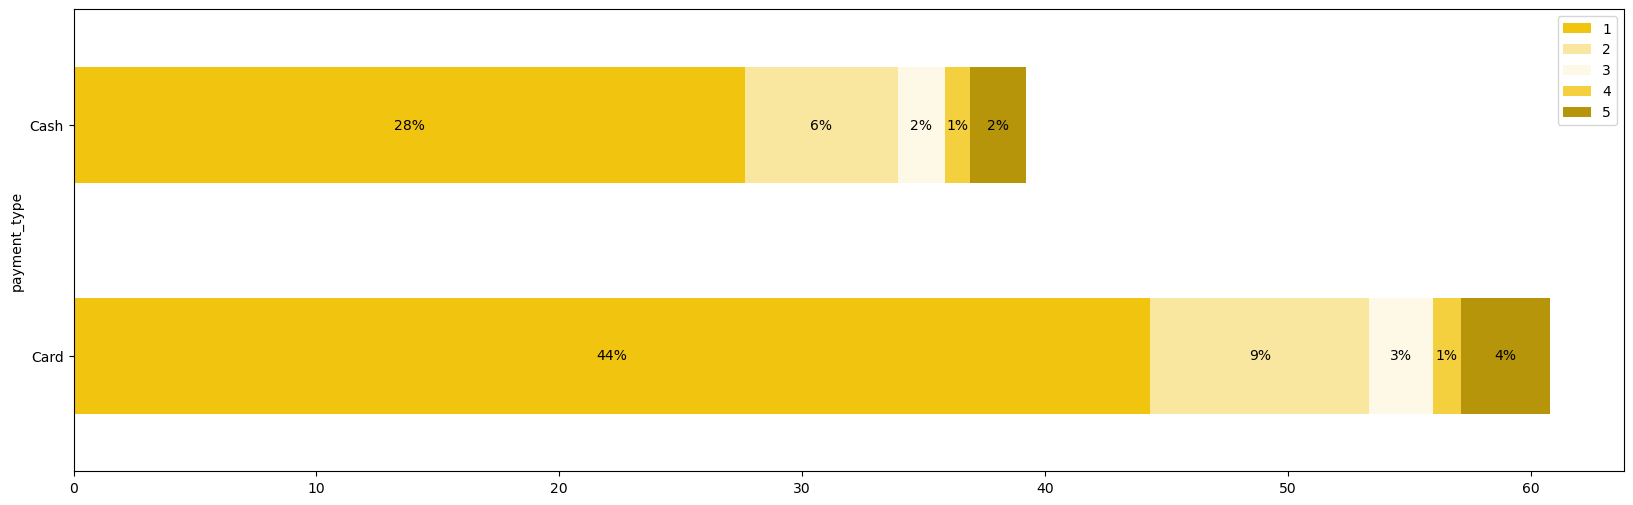

In [42]:
fig,ax = plt.subplots(figsize = (20,6))
df1.plot(x='payment_type', kind='barh', stacked=True, ax = ax ,color=['#F1C40F', '#F9E79F', '#FEF9E7', '#F4D03F', '#B7950B'])
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x,y = p.get_xy()
    ax.text(x + width /2,
            y + height / 2,
            '{:.0f}%'.format(width),
            horizontalalignment = 'center',
            verticalalignment ='center')

    

### Hypothesis
#### Null Hypothesis : There is no difference in avgerage fare between customers who use credit cards and customers who use cash.
#### Alternative Hypothesis : There is a differnce in avg fare between customer who use credit cards and customers who use cash.

In [43]:
card_sample = df[df['payment_type'] == 'Card']['fare_amount']
cash_sample = df[df['payment_type']  == 'Cash']['fare_amount']

In [44]:
t_stats , p_value = st.ttest_ind(a = card_sample,b=cash_sample,equal_var = False)
print('T statistic', t_stats ,'p-value',p_value)

T statistic 182.2972072977547 p-value 0.0
